In [108]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from io import StringIO

from seaborn import load_dataset


In [109]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day20-univariate-analysis/train.csv"
req=requests.get(url).text
data=StringIO(req)
df=pd.read_csv(data)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [110]:
df.drop(columns=["PassengerId"],axis=1,inplace=True)

In [111]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


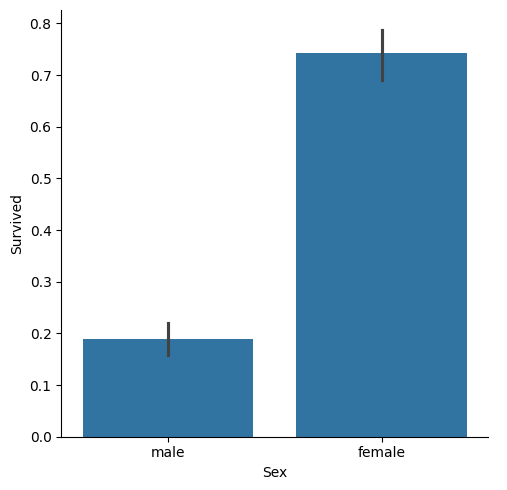

In [112]:
sns.catplot(x=df.Sex ,y=df.Survived,kind="bar")

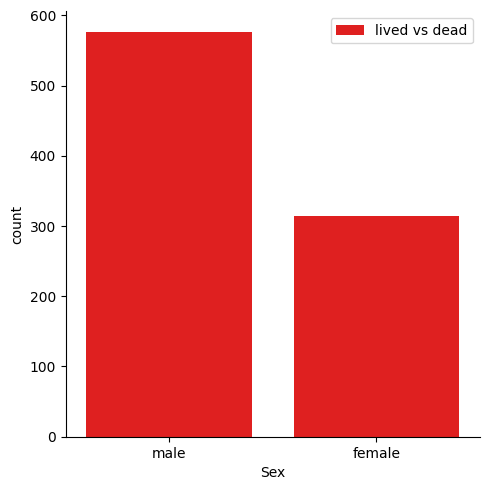

In [113]:
sns.catplot(df.Sex.value_counts(),kind="bar",color="red",label="lived vs dead")
plt.legend()
plt.show()


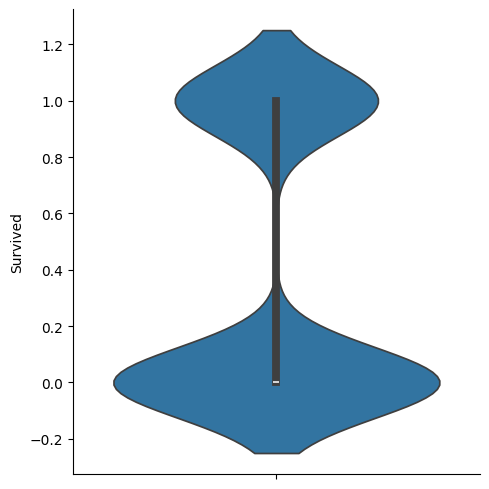

In [114]:
sns.catplot(df["Survived"],kind="violin")

<Axes: ylabel='count'>

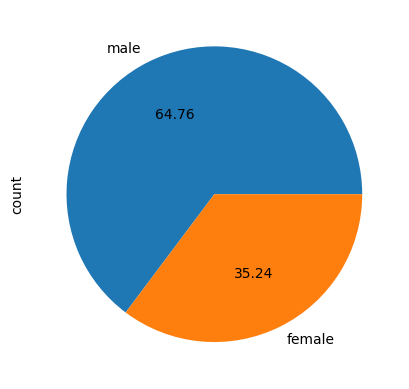

In [115]:
df.Sex.value_counts().plot(kind="pie",autopct="%.2f")

Numerical data


(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

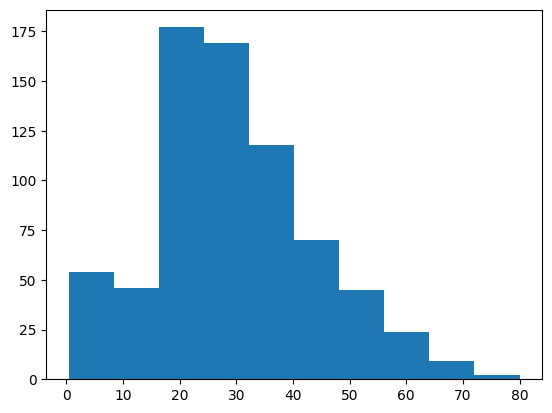

In [116]:
plt.hist(df.Age,bins=10)

/tmp/ipykernel_16583/3446274478.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df.Survived==1].Age,hist=False ,color="red")
/tmp/ipykernel_16583/3446274478.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df.Survived==0].Age,hist=False)


<Axes: xlabel='Age', ylabel='Density'>

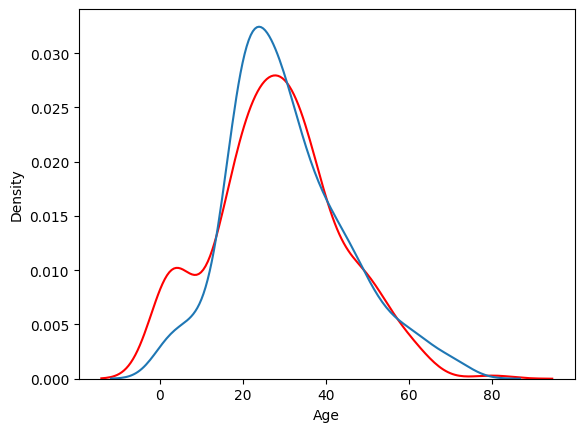

In [117]:
sns.distplot(df[df.Survived==1].Age,hist=False ,color="red")
sns.distplot(df[df.Survived==0].Age,hist=False)

In [118]:
df[df.Survived==1].Age.skew()

np.float64(0.18045773625500755)

Bivariate analysis

In [119]:
tips=load_dataset("tips")
flight=load_dataset("flights")
iris=load_dataset('iris')

In [120]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [121]:
flight

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


<Axes: xlabel='total_bill', ylabel='tip'>

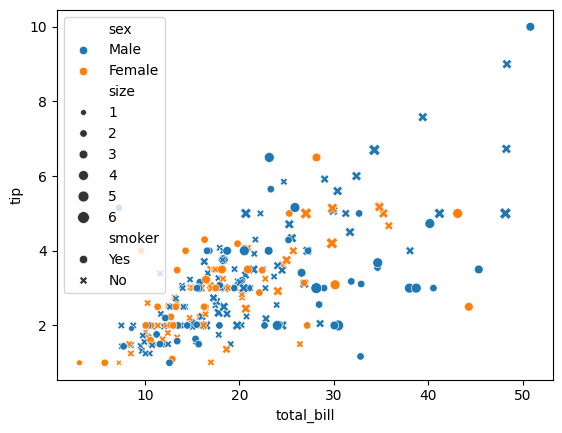

In [122]:
sns.scatterplot(x=tips.total_bill,y=tips.tip,data=tips,hue="sex",style="smoker",size="size")

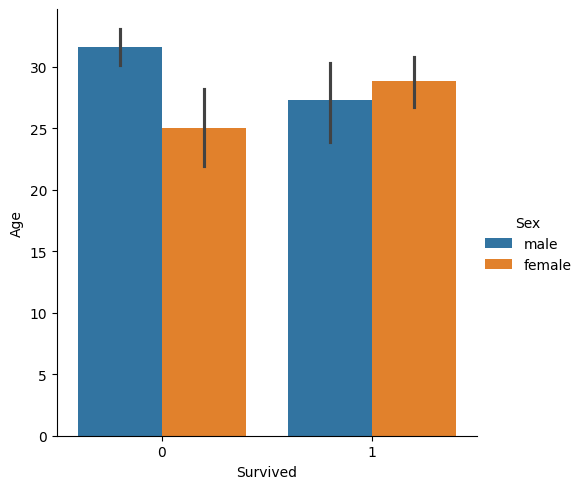

In [123]:
sns.catplot(x=df.Survived,y=df.Age,kind="bar",data=df,hue="Sex")

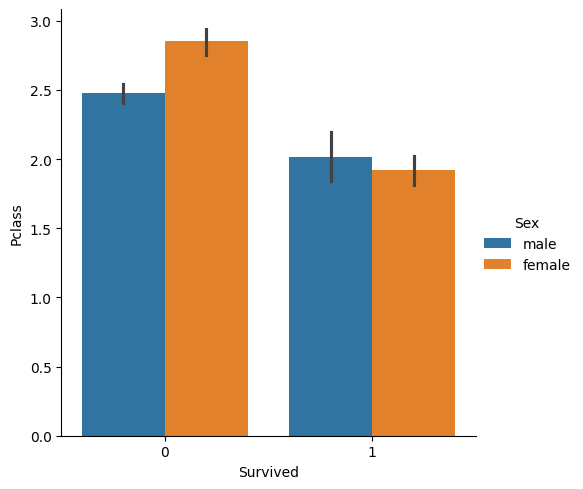

In [124]:
sns.catplot(x=df.Survived,y=df.Pclass,kind="bar",data=df,hue="Sex")

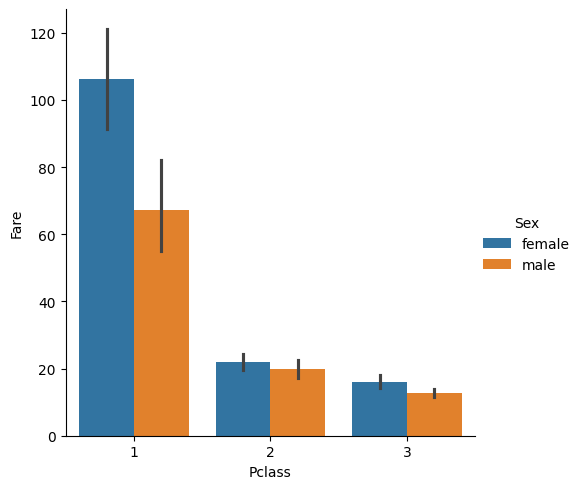

In [125]:
sns.catplot(x=df.Pclass,y=df.Fare,kind="bar",data=df,hue="Sex")

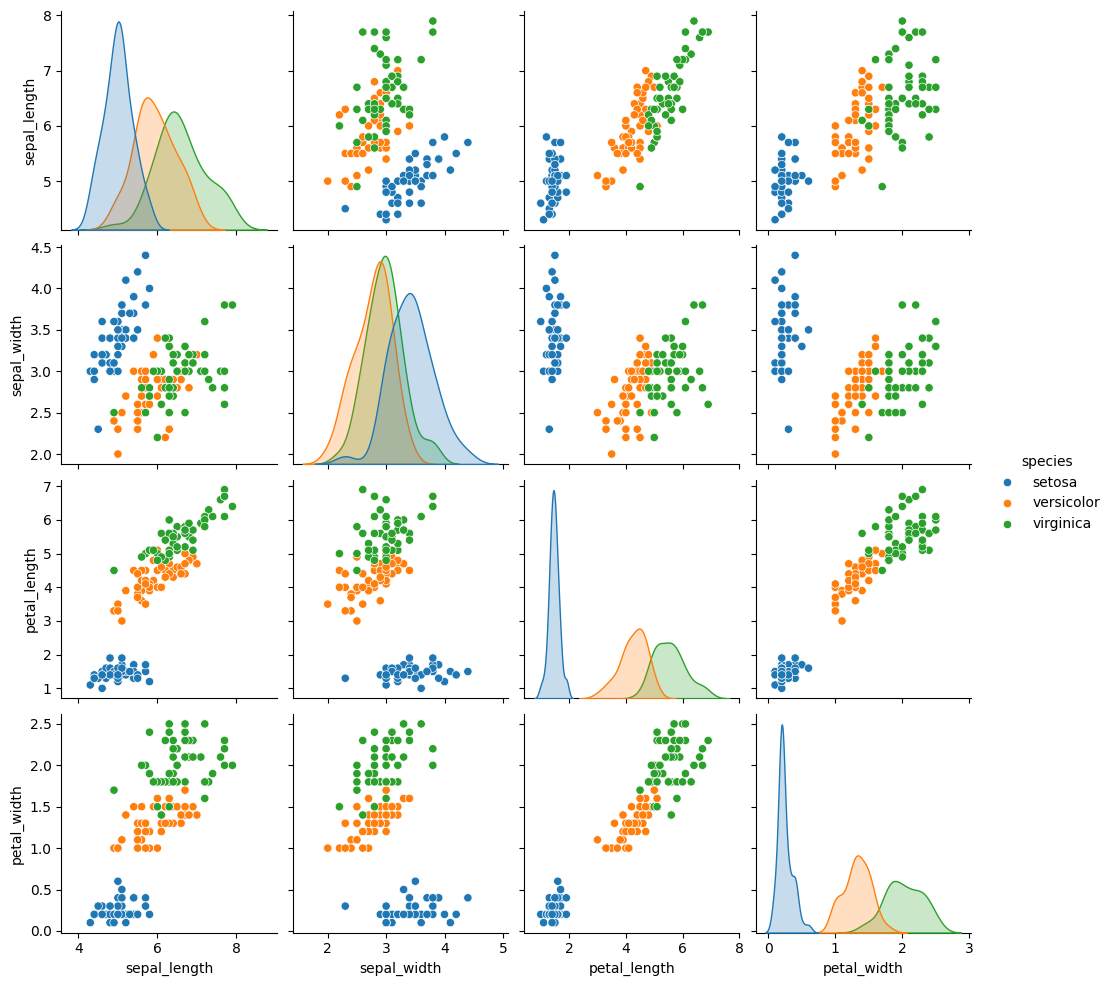

In [126]:
sns.pairplot(iris,hue="species")

<Axes: xlabel='month', ylabel='passengers'>

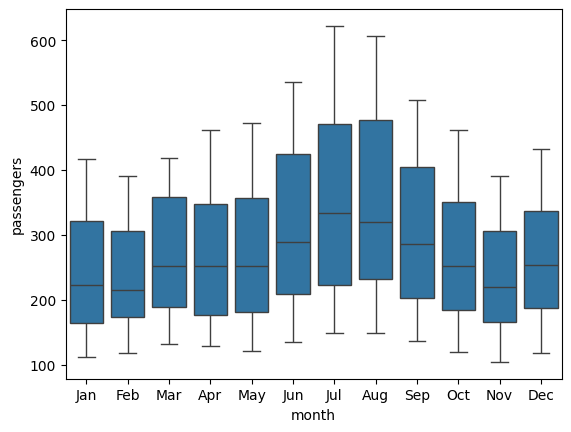

In [127]:
sns.boxplot(x=flight.month,y=flight.passengers)


<Axes: xlabel='Pclass', ylabel='Survived'>

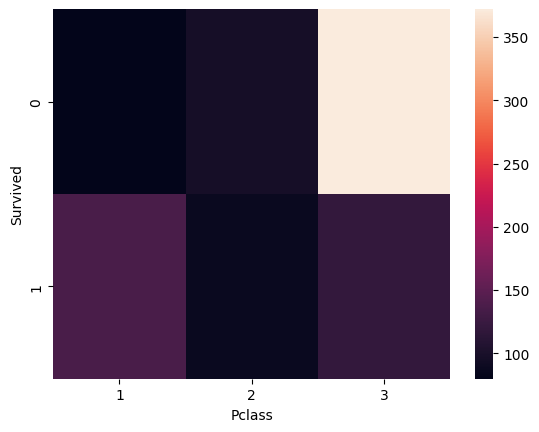

In [128]:
sns.heatmap(pd.crosstab(df.Survived,df.Pclass))

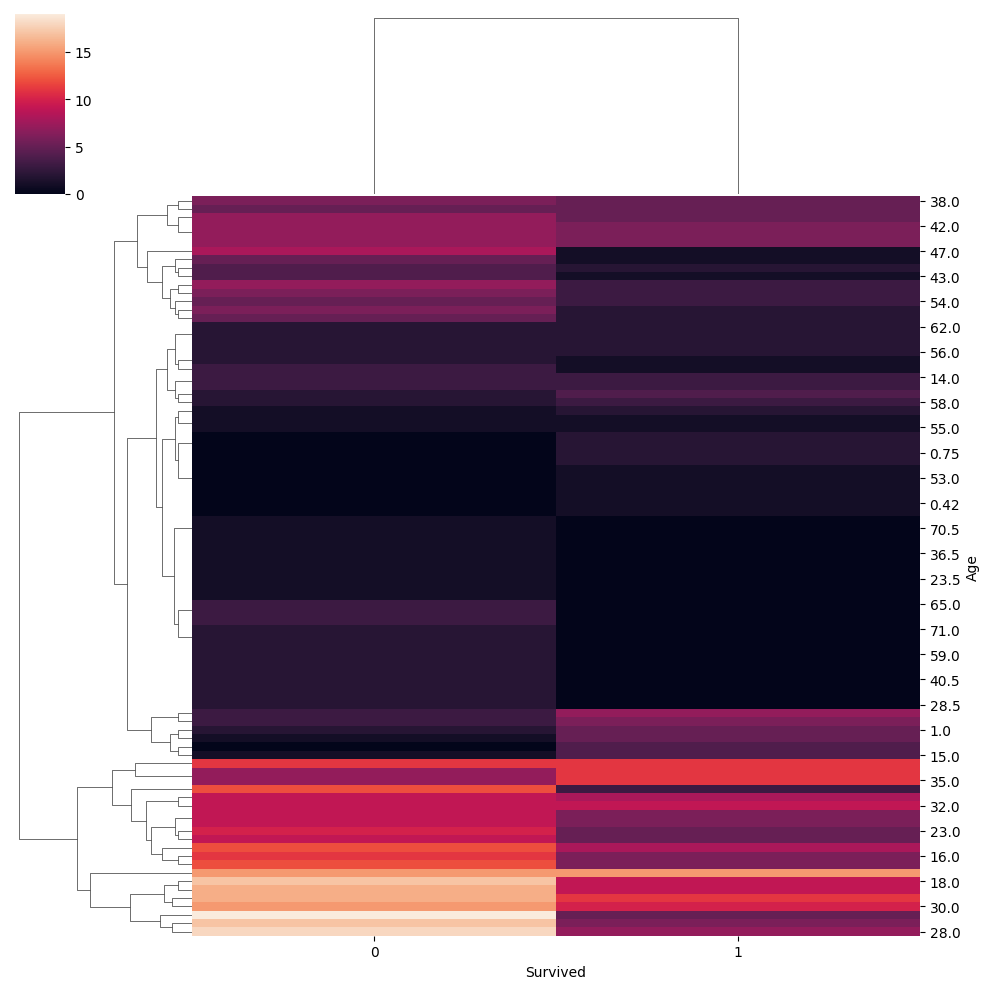

In [ ]:
sns.clustermap(pd.crosstab(df.Age,df.Survived)) #relational study of different Age and Survived showing similar pattern

In [130]:
df.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


/tmp/ipykernel_16583/1679599336.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flight.pivot_table(values="passengers",index="month",columns="year"))


<Axes: xlabel='year', ylabel='month'>

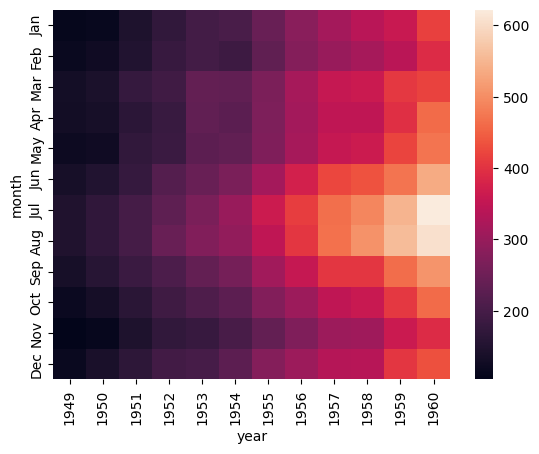

In [133]:
sns.heatmap(flight.pivot_table(values="passengers",index="month",columns="year"))